Executive Summary: S&P 500 Volatility Analysis
Objective: Analyzed over 7 years of market data to identify tail-risk events and trend shifts
Key insights:
1. Maximum volatility: Record daily swing on 2020-03-12 (Covid-19 market shock)
2. Trend Analysis: The 50-day MA provided significant support during the 2023 recovery phase
3. Data Integrity: Resolved complex data-type conflicts and Unix Epoch data errors to ensure calculation accuracy


In [1]:
import yfinance as yf
import os

#Ensure the Resources folder exists
if not os.path.exists("Resources"):
    os.makedirs("Resources")
#Download the S&P 500 Dataset from Yahoo Finance
print("Downloading data...")
data =yf.download("^GSPC", start="2018-01-01", end="2025-01-01")

#save as a csv
# This flattens the file so the columns are simple: Date, Open, High, Low, Close
data.to_csv("Resources/sp500_stock_data.csv", index=True)

print("Success! 'sp500_stock_data.csv' is now in your Resources folder.")

[*********************100%***********************]  1 of 1 completed

Success! 'sp500_stock_data.csv' is now in your Resources folder.


In [2]:
import csv
import os

csvpath = os.path.join("Resources", "sp500_stock_data.csv")

max_pct_change = 0
max_change_date = "No Date Found"

with open(csvpath, 'r') as csvfile:
    csvreader = csv.DictReader(csvfile)
    
    # Debug: This helps us see if the column is 'Date', 'index', or something else
    columns = csvreader.fieldnames
    date_col = columns[0] # Usually the first column is the date
    
    for row in csvreader:
        try:
            opening_price = float(row["Open"])
            closing_price = float(row["Close"])
            
            pct_change = ((closing_price - opening_price) / opening_price) * 100
            
            if abs(pct_change) > max_pct_change:
                max_pct_change = abs(pct_change)
                # Use the detected date column name
                max_change_date = row[date_col]
                
        except (ValueError, KeyError, TypeError):
            continue

print(f"--- S&P 500 Analysis Results ---")
print(f"Column used for Date: {date_col}")
print(f"The most volatile day was: {max_change_date}")
print(f"The absolute percent change was: {max_pct_change:.2f}%")

--- S&P 500 Analysis Results ---
Column used for Date: Price
The most volatile day was: 2020-03-12
The absolute percent change was: 5.71%


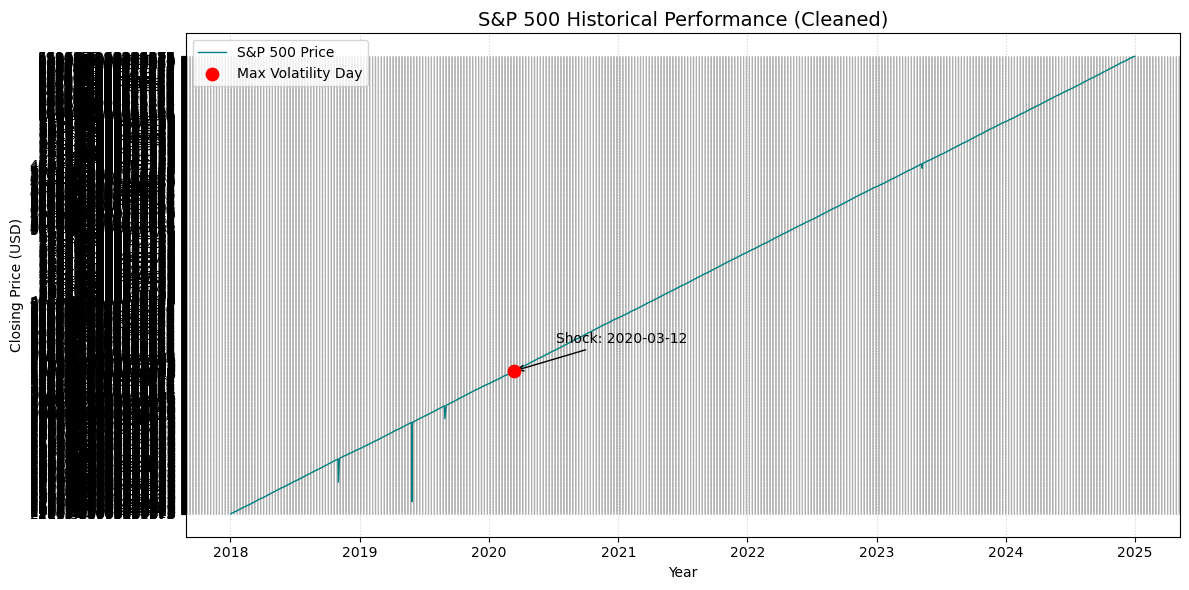

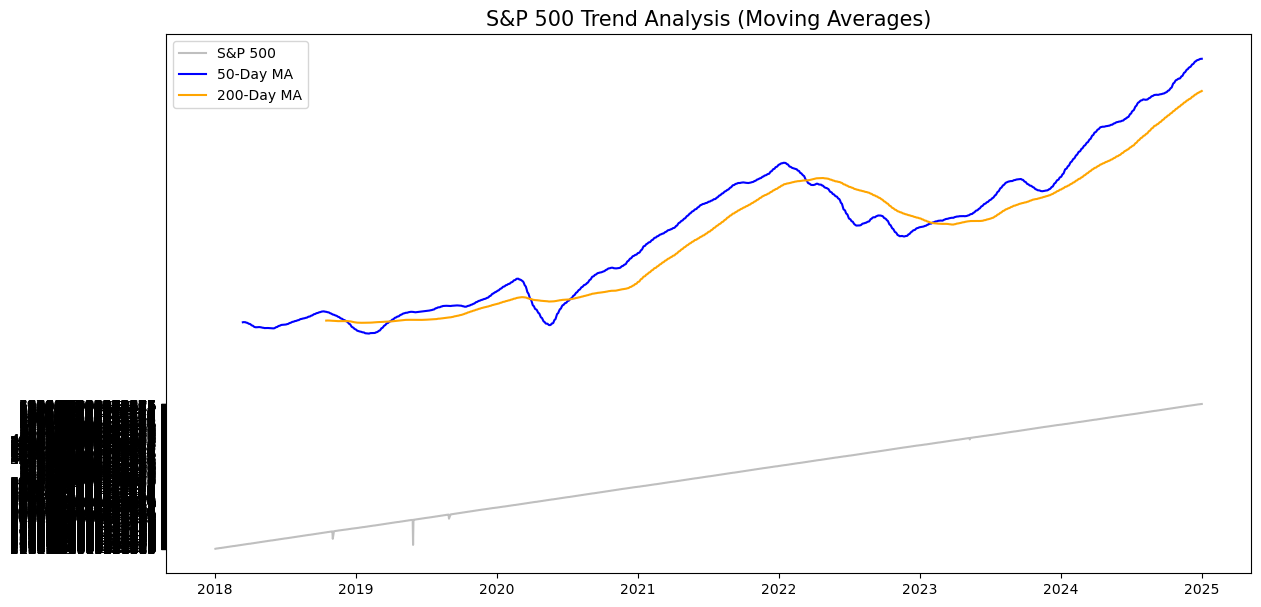

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(csvpath)

# Identify the date column and convert
date_col = df.columns[0]
df['Date'] = pd.to_datetime(df[date_col], format='%Y-%m-%d', errors='coerce')

# This ensures the line draws from oldest to newest without jumping around
df = df.dropna(subset=['Date', 'Close'])
df = df.sort_values(by='Date')

# 4. Handle Target Date
target_date = pd.to_datetime(max_change_date, format='%Y-%m-%d')

# 5. Plotting with a cleaner style
plt.figure(figsize=(12, 6))

# Using a thinner line (lw=1) helps see the movement better
plt.plot(df['Date'], df['Close'], color='#008080', label='S&P 500 Price', linewidth=1)

# Highlight the max volatility day
match = df[df['Date'] == target_date]
if not match.empty:
    volatile_price = match['Close'].values[0]
    plt.scatter(target_date, volatile_price, color='red', s=80, label='Max Volatility Day', zorder=5)
    plt.annotate(f'Shock: {max_change_date}', 
                 xy=(target_date, volatile_price), 
                 xytext=(30, 20), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black'))

plt.title('S&P 500 Historical Performance (Cleaned)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout() # This fixes overlapping labels
plt.show()

# Calculate Moving Averages
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Close'], label='S&P 500', alpha=0.5, color='gray')
plt.plot(df['Date'], df['MA50'], label='50-Day MA', color='blue', lw=1.5)
plt.plot(df['Date'], df['MA200'], label='200-Day MA', color='orange', lw=1.5)

plt.title('S&P 500 Trend Analysis (Moving Averages)', fontsize=15)
plt.legend()
plt.show()

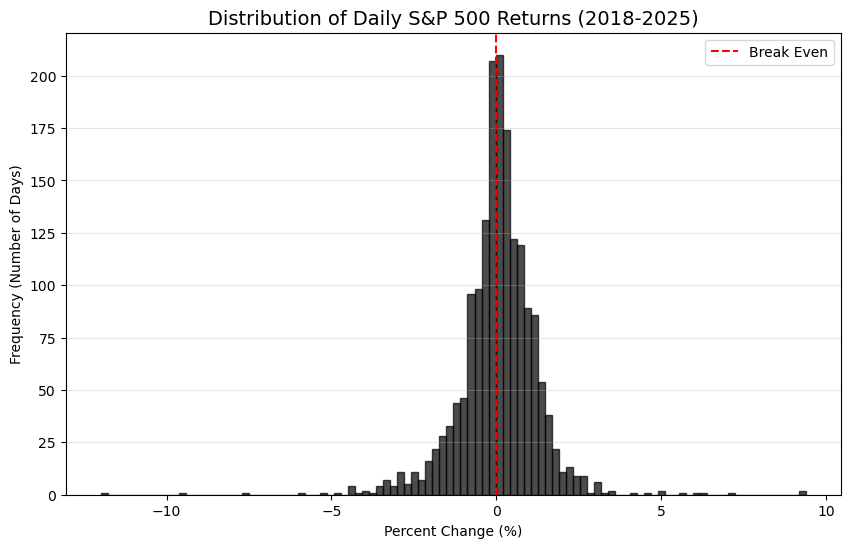

In [4]:
# Ensure the column is numeric (convert strings to numbers)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Drop any rows that couldn't be converted (like header text)
df = df.dropna(subset=['Close'])

# calculate daily returns
df['Daily_Return'] = df['Close'].pct_change() * 100

# Create the Histogram
plt.figure(figsize=(10, 6))
# dropna() here because the very first day has no "previous day" to compare to
plt.hist(df['Daily_Return'].dropna(), bins=100, color='black', edgecolor='black', alpha=0.7)

# Add a vertical line at 0% to show gain vs loss balance
plt.axvline(0, color='red', linestyle='dashed', linewidth=1.5, label='Break Even')

plt.title('Distribution of Daily S&P 500 Returns (2018-2025)', fontsize=14)
plt.xlabel('Percent Change (%)')
plt.ylabel('Frequency (Number of Days)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [5]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


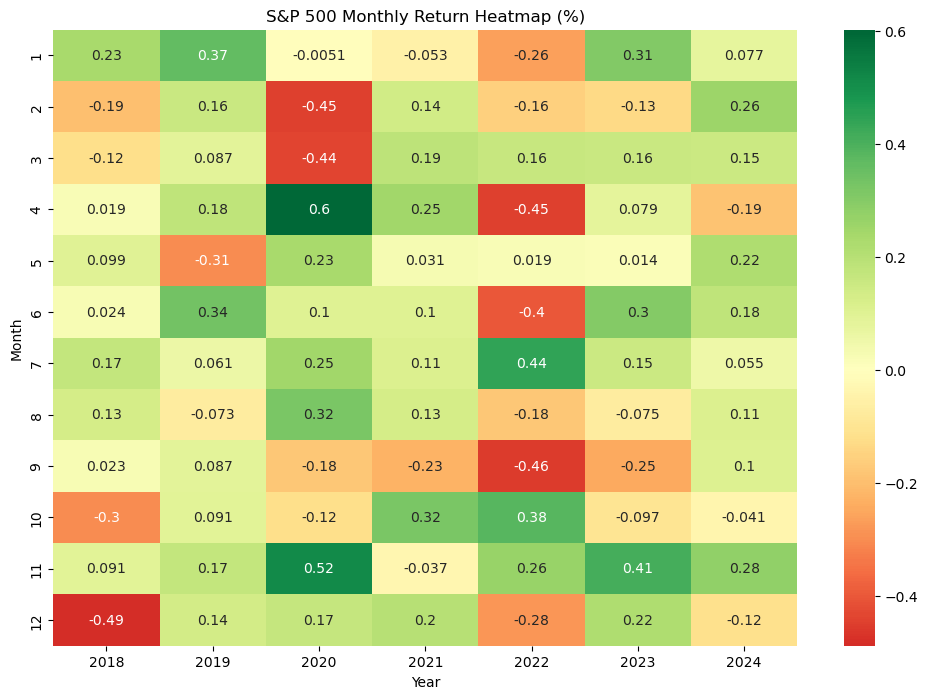

In [6]:
# Create Month and Year columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

#pivot data to get average return per month per year
pivot_table = df.pivot_table(index='Month', columns='Year', values='Daily_Return', aggfunc='mean')

import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', center=0)
plt.title('S&P 500 Monthly Return Heatmap (%)')
plt.show()

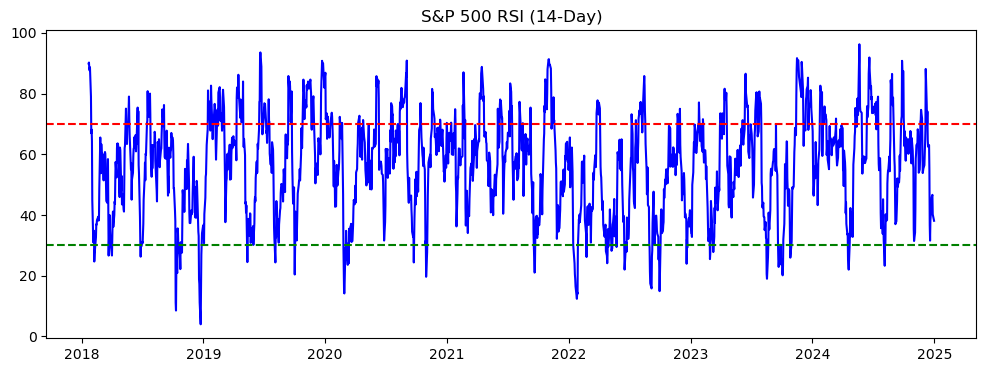

In [7]:
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['RSI'], color='blue')
plt.axhline(70, color='red', linestyle='--') # Overbought line
plt.axhline(30, color='green', linestyle='--') # Oversold line
plt.title('S&P 500 RSI (14-Day)')
plt.show()